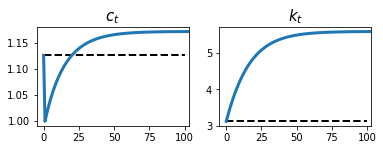

In [2]:
# 貯蓄率の変化と変数の反応(ソローモデル)
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# 変数を定義
k, c, = sp.symbols("k, c")

# パラメータを定義
α, δ, n, s = sp.symbols("α, δ, n, s")
params_0 = {α: 0.3, δ: 0.1, n: -0.01, s: 0.2}
params_1 = {α: 0.3, δ: 0.1, n: -0.01, s: 0.3}


# 関数を定義する
def kapital_func(params, k0): # 資本kの推移式
    F_k = (((1-δ)*k0+s*k0**α)/(1+n)).subs(params)
    k1 = F_k
    
    return k1

def consumption_func(params, k1): # 消費cの推移式
    F_c = ((1-s)*k1**α).subs(params)
    c1 = F_c # numpyに変換

    return c1


# 初期値(定常状態)を計算してもらう
k_star = ((s/(n+δ))**(1/(1-α))).subs(params_0)
k0 = k_star# k_starを初期値に設定
k_list = [k0]
c_list = [consumption_func(params_0, k0)]

# 変数の推移を計算する
T = 120
for i in range(T):
    k1 = kapital_func(params_1, k0)
    k_list.append(k1)
    c_list.append(consumption_func(params_1, k1))
    k0 = np.squeeze(k1)
    
    
k_list = np.array(k_list)
c_list = np.array(c_list)

fig = plt.figure()

ax1 = plt.subplot(2,2,1)
ax1.plot(c_list, linewidth=3)
ax1.set_title(r"$c_{t}$", fontsize=15)
ax1.hlines(c_list[0], 0, 100, linestyle="--", linewidth=2)
ax1.set_xlim(-5, 103)

ax2 = plt.subplot(2,2,2)
ax2.plot(k_list, linewidth=3)
ax2.set_title(r"$k_{t}$", fontsize=15)
ax2.hlines(k_list[0], 0, 100, linestyle="--", linewidth=2)
ax2.set_xlim(-5, 103)

plt.show()